In [15]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import get_dataset
import cnn
import transformer
import ff
import transformers.models.patchtst.modeling_patchtst as ptst_modeling
import transformers.models.patchtst.configuration_patchtst as ptst_config
import importlib
from bayes_opt import BayesianOptimization
from einops import rearrange, repeat

torch.manual_seed(42)

In [3]:
PATH_D = "Series temporales/DNI/"
NUM_S = 3
SENSORS = ["S1", "S3", "S4"]

In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cpu"
print(f"Using {device} device")

Using cpu device


In [22]:
def test_loop(dataloader, model, threshold, tabla_errores, verbose=True):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    patchtst = model.name == "PatchTST"
    num_batches = len(dataloader)
    positive_real, positive_pred, test_loss, correct, correct_pos = 0, 0, 0, 0, 0

    with torch.no_grad():
        total_errores = 0
        for X, y in dataloader:
            #X, y = X.to(device), y.to(device)
            if patchtst:
                X = rearrange(X, 'b c s -> b s c')
 
            # for x_i, y_i in zip(X,y):
            #     y_i = y_i.numpy()
            #     x_i = repeat(x_i, 'c s -> 1 s c')

            pred = model(X)


            for pred_i, y_i in zip(pred,y):
                category = get_dataset.label_to_categories(y_i)
                pred_pos = torch.where(F.sigmoid(pred_i) > threshold, 1, 0)
                pred_pos = pred_pos.numpy()
                y_i = y_i.numpy()
                total_invalidos = (y_i == 1).sum()
                falsos_positivos = ((pred_pos != y_i) & (pred_pos == 1)).sum()
                falsos_negativos = ((pred_pos != y_i) & (pred_pos == 0)).sum()

                error = False

                if (falsos_negativos > 0):
                    error = True
                if (falsos_positivos == NUM_S-total_invalidos):
                    error = True

                col_fp = str(falsos_positivos) + ' FP'
                col_fn = str(falsos_negativos) + ' FN'

                if tabla_errores is not None:
                    tabla_errores.loc[category, col_fp] += 1
                    tabla_errores.loc[category, col_fn] += 1
                    tabla_errores.loc[category, 'Error'] += error
                total_errores += error

            pred_pos = torch.where(F.sigmoid(pred) > threshold, 1, 0)
            real_pos = (y == 1.0)

            positive_pred += pred_pos.type(torch.float).sum().item()
            positive_real += y.type(torch.float).sum().item()
            correct_pos += torch.bitwise_and(pred_pos,real_pos).type(torch.float).sum().item()
            correct += (pred_pos == y).type(torch.float).sum().item()

        test_loss /= num_batches
        correct /= 3*num_batches*dataloader.batch_size
        if (positive_pred != 0):
            precission = correct_pos/positive_pred
        else:
            precission = 0.0
        if (positive_real != 0):
            recall = correct_pos/positive_real
        else:
            recall = 0.0
        if (precission+recall > 0):
            f1score = 2*precission*recall/(precission+recall)
        else:
            f1score = 0

        if (verbose):
            print(f"Accuracy: \t {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}")
            print(f"Precission: \t {(100*precission):>0.1f}%")
            print(f"Recall: \t {(100*recall):>0.1f}%")
            print(f"F1-score: \t {(f1score):>0.3f}")

    if tabla_errores is None:
        return total_errores
    else:
        return tabla_errores, total_errores

In [6]:
def print_metrics(best_score, best_epoch, loss, accuracy, precission, recall):
    print(f"Accuracy: \t {(100*accuracy):>0.1f}%")
    print(f"Precission: \t {(100*precission):>0.1f}%")
    print(f"Recall: \t {(100*recall):>0.1f}%")
    print(f"F1-score: \t {(best_score):>0.4f}")
    print(f"Loss: \t {(loss):>0.4f}")
    print(f"Mejor epoch: \t {(best_epoch)}")

In [7]:
batch_size = 16
memory = 1
importlib.reload(get_dataset)
train_ds, test_ds, val_ds, weights = get_dataset.get_dataset(0.20,0.20,sequential=False,coef_weights=1,random_state=42,device=device)

Categorías entrenamiento:
[0 1 2 3 4 5 6 7]
[855 143 186   3 203   7  17   8]
Categorías validación:
[0 1 2 3 4 5 6 7]
[285  47  62   1  67   3   6   3]
Categorías test:
[0 1 2 3 4 5 6 7]
[286  48  62   1  68   2   6   2]


In [8]:
test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False,drop_last=True)
val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,drop_last=True)

In [52]:
def errores_ff(thres):
    model = ff.FF(
    num_sensors=NUM_S,
    layer1=200,
    layer2=200
    ).to(device)

    model.load_state_dict(torch.load('mejor_modelo_' + model.name + '.pth'))
    total_errores = test_loop(test_loader, model,threshold=thres,tabla_errores=None,verbose=False)
    return total_errores

def errores_cnn(thres):
    model = cnn.CNN(
    num_sensors=NUM_S,
    batch_size=batch_size,
    channels=[4,3,2],
    kernels=[4,4,4],
    dense=[200,13]
    ).to(device)

    model.load_state_dict(torch.load('mejor_modelo_' + model.name + '.pth'))
    total_errores = test_loop(test_loader, model,threshold=thres,tabla_errores=None,verbose=False)
    return total_errores

def errores_vit(thres):
    model = transformer.ViT(
    series_length=144,
    patch_length=6,
    num_sensors=NUM_S,
    dim=12,
    depth=4,
    heads=4,
    dim_head=7,
    mlp_dim=7,
    dropout=0.1, #0.2
    emb_dropout=0.1, #0.2
    ).to(device)

    model.load_state_dict(torch.load('mejor_modelo_' + model.name + '.pth'))
    total_errores = test_loop(test_loader, model,threshold=thres,tabla_errores=None,verbose=False)
    return total_errores

def errores_ptst(thres):
    config = ptst_config.PatchTSTConfig(
    num_input_channels=NUM_S,
    num_targets=3,
    d_model=12,
    ffn_dim=102,
    context_length=144,
    patch_length=12,
    patch_stride=12,
    use_cls_token=False,
    num_attention_heads=3,
    num_hidden_layers=3,
    channel_attention=True,
    attention_dropout=0.1, #0.187
    positional_dropout=0.1, #0.086
    )
    model = ptst_modeling.PatchTSTForClassification(config).to(device)

    model.load_state_dict(torch.load('mejor_modelo_PatchTST_ca_true.pth'))
    total_errores = test_loop(test_loader, model,threshold=thres,tabla_errores=None,verbose=False)
    return total_errores

In [53]:
umbrales = np.arange(0,0.5,0.01)
print("Umbrales:")
print(umbrales)

func_errores = [[errores_ff, "FF"], [errores_cnn,"CNN"], [errores_vit,"ViT"], [errores_ptst,"PTST"]]
errores_por_umbral = []

for f, name in func_errores:
    errores_por_umbral_modelo = []
    for umbral in umbrales:
        errores_por_umbral_modelo.append(f(umbral))
    errores_por_umbral.append(errores_por_umbral_modelo.copy())
    print(name)
    print(errores_por_umbral_modelo)
    minimo = min(errores_por_umbral_modelo)
    print("minimo:", minimo,"| umbral:",umbrales[errores_por_umbral_modelo.index(minimo)])   


Umbrales:
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49]
FF
[464, 461, 434, 426, 421, 413, 378, 377, 372, 371, 368, 358, 337, 330, 194, 189, 186, 46, 42, 39, 37, 35, 32, 32, 26, 23, 25, 24, 29, 29, 28, 28, 29, 32, 33, 40, 54, 54, 54, 56, 56, 56, 56, 56, 56, 56, 56, 57, 57, 57]
minimo: 23 | umbral: 0.25
CNN
[464, 61, 55, 49, 44, 38, 35, 31, 28, 25, 23, 20, 20, 19, 17, 17, 16, 16, 16, 16, 17, 18, 18, 18, 18, 18, 19, 18, 18, 18, 18, 18, 19, 19, 19, 20, 20, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 23]
minimo: 16 | umbral: 0.16
ViT
[464, 67, 36, 26, 28, 26, 26, 26, 24, 24, 24, 23, 22, 22, 22, 22, 23, 22, 22, 22, 21, 18, 18, 18, 18, 20, 21, 21, 21, 21, 21, 22, 22, 21, 21, 23, 22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23]
minimo: 18 | umbral: 0.21
PTST
[464, 300, 251, 194

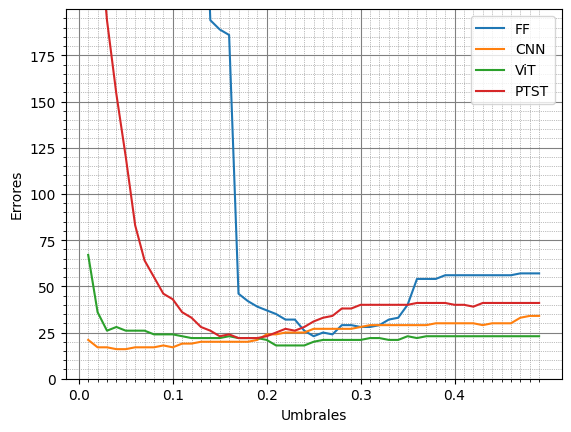

In [51]:
for i in range(len(errores_por_umbral)):
    plt.plot(umbrales[1:],errores_por_umbral[i][1:],label=func_errores[i][1])
    plt.ylabel("Errores")
    plt.ylim(0,200)

    plt.xticks(np.arange(0, 0.5, 0.1))
    plt.yticks(np.arange(0, 200, 25))
    plt.xticks(np.arange(0, 0.5, 0.01), minor=True)
    plt.yticks(np.arange(0, 200, 5), minor=True)
    plt.grid(which='major', linestyle='-', linewidth=0.8, color='gray')
    plt.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')
    plt.legend()
    plt.savefig("umbrales.svg")
    plt.xlabel("Umbrales")

In [56]:
importlib.reload(cnn)
importlib.reload(transformer)
importlib.reload(ff)

models = []

# models.append((ff.FF(
#     num_sensors=NUM_S,
#     layer1=200,
#     layer2=200
# ).to(device),0.25,0.001))

models.append((cnn.CNN(
    num_sensors=NUM_S,
    batch_size=batch_size,
    channels=[4,3,2],
    kernels=[4,4,4],
    dense=[200,13]
    ).to(device),0.5,0.001))

models.append((cnn.CNN(
    num_sensors=NUM_S,
    batch_size=batch_size,
    channels=[4,3,2],
    kernels=[4,4,4],
    dense=[200,13]
    ).to(device),0.17,0.001))


# models.append((transformer.ViT(
#     series_length=144,
#     patch_length=6,
#     num_sensors=NUM_S,
#     dim=12,
#     depth=4,
#     heads=4,
#     dim_head=7,
#     mlp_dim=7,
#     dropout=0.1, #0.2
#     emb_dropout=0.1, #0.2
# ).to(device),0.23,0.001))



# config = ptst_config.PatchTSTConfig(
#     num_input_channels=NUM_S,
#     num_targets=3,
#     d_model=12,
#     ffn_dim=102,
#     context_length=144,
#     patch_length=12,
#     patch_stride=12,
#     use_cls_token=False,
#     num_attention_heads=3,
#     num_hidden_layers=3,
#     channel_attention=True,
#     attention_dropout=0.1, #0.187
#     positional_dropout=0.1, #0.086
#     )
# models.append((ptst_modeling.PatchTSTForClassification(config).to(device),0.5,0.001))

dataframes = []

for model, thres, lr in models:

    tabla_errores = pd.DataFrame(
        {'Total':{0:0,4:0,2:0,1:0,6:0,5:0,3:0,7:0},
            '0 FP':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '1 FP':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '2 FP':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '3 FP':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '0 FN':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '1 FN':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '2 FN':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            '3 FN':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0},
            'Error':{0:0,1:0,2:0,4:0,3:0,5:0,6:0,7:0}
            }
    )

    for X, y in test_loader:
        for i in y:
            tabla_errores.loc[get_dataset.label_to_categories(i), 'Total'] += 1

    criterion = nn.BCEWithLogitsLoss(pos_weight=(weights).to(device))
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)

    print("MODEL: " + model.name)
    if model.name == "PatchTST":
        model.load_state_dict(torch.load('mejor_modelo_PatchTST_ca_true.pth'))
    else:
        model.load_state_dict(torch.load('mejor_modelo_' + model.name + '.pth'))
    #(dataloader, model, threshold, tabla_errores, verbose=True
    tabla_errores, total_errores = test_loop(test_loader, model,threshold=thres,tabla_errores=tabla_errores,verbose=True)
        
    # tabla_errores.style \
    # .format(precision=3, thousands=".", decimal=",") \
    # .format_index(str.upper, axis=1) \
    #.relabel_index(["row 1", "row 2"], axis=0)

    print(tabla_errores.index)
    print("Total errores: ", total_errores)
    tabla_errores = tabla_errores.rename({0:'V V V', 
                                1:'V V I', 
                                2:'V I V',
                                3:'V I I',
                                4:'I V V',
                                5:'I V I',
                                6:'I I V',
                                7:'I I I'},axis='index')
    #dataframes.append(tabla_errores.copy())
    display(tabla_errores)
    tabla_errores.style \
    .format(precision=3, thousands=".", decimal=",") \
    .format_index(str.upper, axis=1)

    print(tabla_errores.to_latex(caption="Errores de "+model.name,label='errores '+model.name))



MODEL: CNN
Accuracy: 	 95.8%, Avg loss: 0.000000
Precission: 	 83.3%
Recall: 	 88.4%
F1-score: 	 0.858
Index([0, 4, 2, 1, 6, 5, 3, 7], dtype='int64')
Total errores:  23


,Total,0 FP,1 FP,2 FP,3 FP,0 FN,1 FN,2 FN,3 FN,Error
V V V,278,252,25,1,0,278,0,0,0,0
I V V,67,64,2,1,0,59,8,0,0,9
V I V,61,60,0,1,0,57,4,0,0,4
V V I,48,46,2,0,0,44,4,0,0,4
I I V,6,6,0,0,0,4,2,0,0,2
I V I,1,1,0,0,0,0,1,0,0,1
V I I,1,1,0,0,0,0,1,0,0,1
I I I,2,2,0,0,0,0,1,1,0,2


\begin{table}
\caption{Errores de CNN}
\label{errores CNN}
\begin{tabular}{lrrrrrrrrrr}
\toprule
 & Total & 0 FP & 1 FP & 2 FP & 3 FP & 0 FN & 1 FN & 2 FN & 3 FN & Error \\
\midrule
V V V & 278 & 252 & 25 & 1 & 0 & 278 & 0 & 0 & 0 & 0 \\
I V V & 67 & 64 & 2 & 1 & 0 & 59 & 8 & 0 & 0 & 9 \\
V I V & 61 & 60 & 0 & 1 & 0 & 57 & 4 & 0 & 0 & 4 \\
V V I & 48 & 46 & 2 & 0 & 0 & 44 & 4 & 0 & 0 & 4 \\
I I V & 6 & 6 & 0 & 0 & 0 & 4 & 2 & 0 & 0 & 2 \\
I V I & 1 & 1 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 1 \\
V I I & 1 & 1 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 1 \\
I I I & 2 & 2 & 0 & 0 & 0 & 0 & 1 & 1 & 0 & 2 \\
\bottomrule
\end{tabular}
\end{table}

MODEL: CNN
Accuracy: 	 90.4%, Avg loss: 0.000000
Precission: 	 60.6%
Recall: 	 93.9%
F1-score: 	 0.737
Index([0, 4, 2, 1, 6, 5, 3, 7], dtype='int64')
Total errores:  16


,Total,0 FP,1 FP,2 FP,3 FP,0 FN,1 FN,2 FN,3 FN,Error
V V V,278,217,57,4,0,278,0,0,0,0
I V V,67,61,5,1,0,62,5,0,0,6
V I V,61,19,41,1,0,57,4,0,0,4
V V I,48,43,4,1,0,46,2,0,0,3
I I V,6,6,0,0,0,6,0,0,0,0
I V I,1,1,0,0,0,1,0,0,0,0
V I I,1,1,0,0,0,0,1,0,0,1
I I I,2,2,0,0,0,2,0,0,0,2


\begin{table}
\caption{Errores de CNN}
\label{errores CNN}
\begin{tabular}{lrrrrrrrrrr}
\toprule
 & Total & 0 FP & 1 FP & 2 FP & 3 FP & 0 FN & 1 FN & 2 FN & 3 FN & Error \\
\midrule
V V V & 278 & 217 & 57 & 4 & 0 & 278 & 0 & 0 & 0 & 0 \\
I V V & 67 & 61 & 5 & 1 & 0 & 62 & 5 & 0 & 0 & 6 \\
V I V & 61 & 19 & 41 & 1 & 0 & 57 & 4 & 0 & 0 & 4 \\
V V I & 48 & 43 & 4 & 1 & 0 & 46 & 2 & 0 & 0 & 3 \\
I I V & 6 & 6 & 0 & 0 & 0 & 6 & 0 & 0 & 0 & 0 \\
I V I & 1 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
V I I & 1 & 1 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 1 \\
I I I & 2 & 2 & 0 & 0 & 0 & 2 & 0 & 0 & 0 & 2 \\
\bottomrule
\end{tabular}
\end{table}



In [69]:
print("Suma total", tabla_errores['Total'].sum())

Suma total 464
